### Imports and Ray Initialization

In [1]:
import ray
import os
import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt
import seaborn as sns
from agamoo_ray import AGAMOO, Evaluator
from agamoo_ray.players import ClonalSelection
from agamoo_ray.objectives.pymoo_wrapper import ProblemPymoo
from pymoo.problems import get_problem

from pygmo import hypervolume

def normalize(values, fmin, fmax):
    return (values - fmin) / (fmax - fmin)

# Initialize the Ray distributed execution engine
os.environ["RAY_ACCEL_ENV_VAR_OVERRIDE_ON_ZERO"] = "0"
if not ray.is_initialized():
    ray.init()

2026-04-22 08:26:06,011	INFO worker.py:1998 -- Started a local Ray instance. View the dashboard at 127.0.0.1:8266 


### Pymoo Wrapper Initialization

In [2]:
# Load the DTLZ3 problem from Pymoo (known for highly multimodal landscapes)
n_vars = 10
n_objs = 3
pymoo_dtlz3 = get_problem("dtlz3", n_var=n_vars, n_obj=n_objs)

### Solving the problem with AGAMOO_Ray

In [3]:
max_eval = 100000
max_front = 100
change_iter = 1
next_iter = -1
log_freq = 5
npop = 25
player_parm = { "nclone": 12, "mutate_args": [0.2, 0.85, 0.005], 'sup': 0.0, 'strategy': 'base'}

In [4]:
objs = [ProblemPymoo(num=i, obj=i+1, pymoo_prob=pymoo_dtlz3) for i in range(n_objs)]

In [5]:
agamoo = AGAMOO(max_eval, change_iter, next_iter, max_front, assign_gens='random', log_freq=log_freq)
storage = agamoo.create_storage(n_vars, n_objs, num_cpus=n_objs)
evaluators = [Evaluator.options(num_cpus=1).remote(objs) for _ in range(len(objs)-1)]
players = [ClonalSelection.options(num_cpus=1).remote(i, npop, player_parm, obj, storage, gens='pattern', exchange='front_sup') for i, obj in zip(range(n_objs), objs)]
agamoo.init_players(players, evaluators)
agamoo.start_optimize(tqdm_disable=False)
res = agamoo.get_results()
hist = agamoo.get_history()

  0%|          | 0/100000 [00:00<?, ?eval/s]

### Pareto front

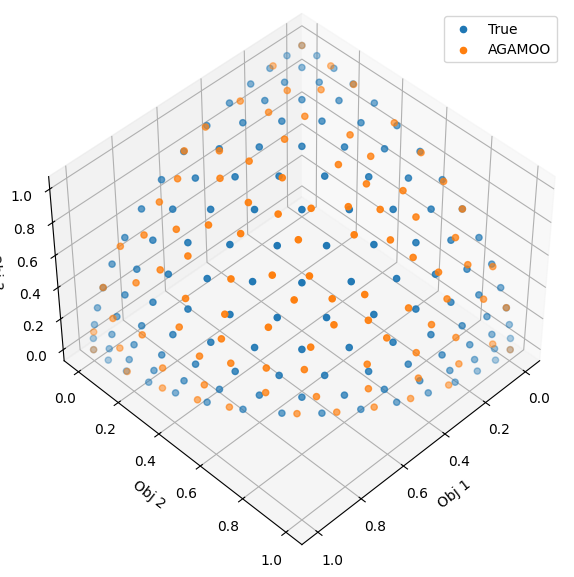

In [6]:
true_front = pymoo_dtlz3.pareto_front()
f_eval = res['front_eval']
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(true_front[:, 0], true_front[:, 1], true_front[:, 2], label='True')
sc = ax.scatter(f_eval[:, 0], f_eval[:, 1], f_eval[:, 2], label='AGAMOO')
ax.set_xlabel('Obj 1')
ax.set_ylabel('Obj 2')
ax.set_zlabel('Obj 3')
ax.view_init(45,45)
plt.legend()
plt.show()

### Convergence plot of the HV indicator

In [11]:
ref_point = np.ones(3)*1.1
data = {'Iter': [], 'Neval': [], 'Time': [], 'HV': []}
for i in range(1,len(hist)):
    data['Iter'].append(hist[i]['iteration'])
    data['Neval'].append(np.min(hist[i]['nfe_array']))
    data['Time'].append(hist[i]['wall_clock_time']/1.e9)
    front_eval = hist[i]['front_eval']
    if hist[i]['iteration'] == 0:
        data['HV'].append(0.0)
    else:
        mask = np.any(front_eval>=1.1, axis=1)
        front_eval = front_eval[np.logical_not(mask)]
        if len(front_eval)<1:
            data['HV'].append(0.0)
        else:
            hv = hypervolume(front_eval).compute(ref_point)
            data['HV'].append(hv)

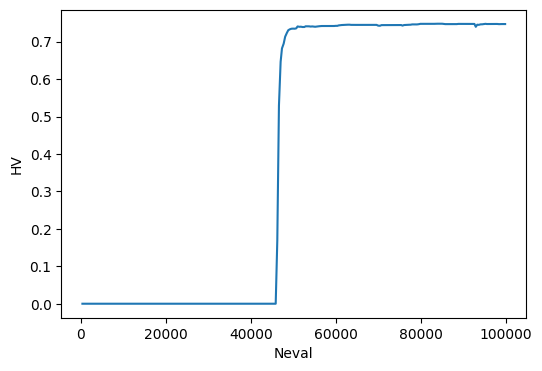

In [12]:
fig = plt.figure(figsize=(6, 4))
ax = fig.add_subplot(111)
sc1 = ax.plot(data['Neval'], data['HV'])
ax.set_xlabel('Neval')
ax.set_ylabel('HV')
plt.show()